# 한글 폰트 설치

In [1]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [1]:
import matplotlib.pyplot as plt
import platform
import seaborn as sns
import matplotlib.font_manager as fm     # 시스템에 설치된 폰트를 탐색하고 그래프 폰트로 등록해주는 매니저

# 한국어 폰트 설정 ───────────────────────────────────────────────────
font_dirs = ['/usr/share/fonts/truetype/nanum']         # 나눔 폰트가 설치되어 있는 시스템 폴더 경로 지정
font_files = fm.findSystemFonts(fontpaths=font_dirs)    # 지정한 경로에서 폰트 파일(.ttf) 목록을 모두 찾아 리스트로 반환
for ff in font_files:
    fm.fontManager.addfont(ff)                          # 찾은 개별 폰트 파일들을 Matplotlib 폰트 매니저에 사용할 수 있도록 등록

# ── 5. 시각화 전역 설정 (Wilke 스타일 + 폰트 통합) ──────────────────────────────
# Seaborn 테마 설정 (여기에 폰트를 지정해야 sns 그래프에서도 한글이 깨지지 않음)
sns.set_theme(
    style='whitegrid',                  # 배경을 하얗고 옅은 격자가 있는 스타일로 설정
    rc={
        'font.family': 'NanumBarunGothic', # 그래프의 기본 글꼴을 등록해둔 '나눔바른고딕'으로 설정 (한글 깨짐 방지)
        'axes.unicode_minus': False        # 한글 폰트 적용 시 축의 마이너스(-) 기호가 네모로 깨지는 현상 방지
    }
)

# Matplotlib 세부 스타일 설정 (흰 배경, 최소 격자, 고해상도)
plt.rcParams.update({
    'figure.dpi': 130,                  # 그래프의 해상도를 130 DPI로 설정하여 선명하게 출력
    'figure.facecolor': 'white',        # 그래프 바깥쪽 영역(Figure)의 배경색을 흰색으로 설정
    'axes.facecolor': '#FAFAFA',        # 그래프 안쪽 영역(Axes)의 배경색을 아주 옅은 회색으로 설정
    'axes.spines.top': False,           # 그래프의 위쪽 테두리 선을 숨김 (깔끔한 시각화를 위해)
    'axes.spines.right': False,         # 그래프의 오른쪽 테두리 선을 숨김
    'axes.grid': True,                  # 그래프 내부에 격자선을 표시하도록 설정
    'grid.alpha': 0.3,                  # 격자선의 투명도를 0.3으로 설정 (연하게 표시)
    'grid.linestyle': '--',             # 격자선의 모양을 점선(dash)으로 설정
    'axes.titlesize': 13,               # 그래프 제목(Title)의 글씨 크기를 13으로 설정
    'axes.labelsize': 11,               # x축, y축 이름(Label)의 글씨 크기를 11로 설정
    'xtick.labelsize': 9,               # x축 눈금 숫자들의 글씨 크기를 9로 설정
    'ytick.labelsize': 9,               # y축 눈금 숫자들의 글씨 크기를 9로 설정
    'legend.fontsize': 9,               # 범례(Legend)의 글씨 크기를 9로 설정
})

print('라이브러리 로드 및 시각화 환경 설정 완료')

라이브러리 로드 및 시각화 환경 설정 완료


- 테스트

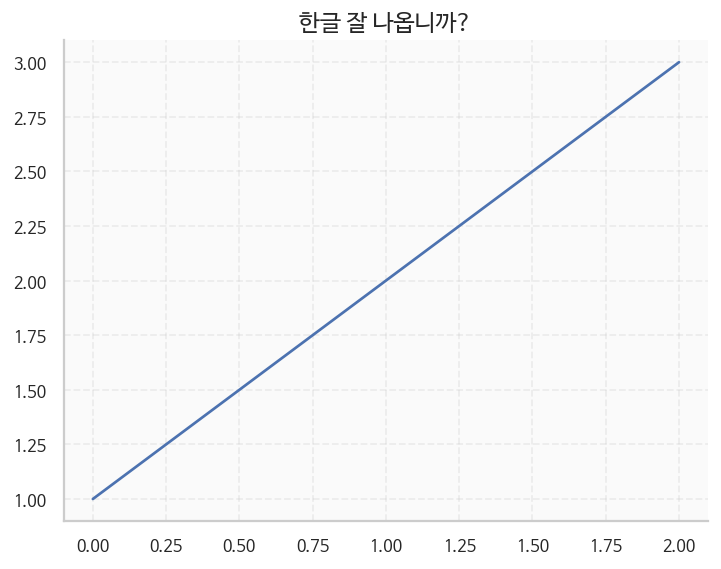

In [2]:
plt.plot([1, 2, 3])
plt.title("한글 잘 나옵니까?")
plt.show()

# 라이브러리 불러오기
- matplotlib.dates (mdates)
  + 시계열 그래프를 그릴 때 x축의 날짜가 겹치거나 보기 힘들게 표시되는 것을 방지합니다.
  + 특정 간격(예: 3개월 단위)으로 눈금을 표시하거나, 날짜 형식을 %Y-%m 등으로 지정할 때 사용합니다.
- seasonal_decompose (전통적 시계열 분해)
  + 원리: 이동 평균(Moving Average)을 사용하여 시계열을 추세(Trend), 계절성(Seasonal), 잔차(Resid)로 나눕니다.
  + 장점: 계산이 빠르고 직관적입니다.
  + 단점: * 데이터의 앞부분과 뒷부분에 결측치(NaN)가 발생합니다.
    - 계절 성분이 시간에 따라 변하지 않는다고 가정하므로, 급격한 변화가 있는 데이터에는 취약합니다.
- STL (Seasonal-Trend decomposition using LOESS)
  + 원리: 'LOESS(Local Regression)'라는 국소 회귀 기법을 반복 사용하여 분해합니다.
  + 장점: * 유연성: 계절 성분이 시간에 따라 변하는 것을 허용합니다.
    - 강건함: 이상치(Outlier)가 있어도 추세나 계절 성분이 크게 왜곡되지 않습니다.
    - 데이터 양 끝에 결측치가 생기지 않아 실무에서 훨씬 선호되는 방식입니다.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # 축의 날짜 포맷(년/월/일)을 세밀하게 조절하는 도구

# statsmodels: 통계 모델링 및 시계열 분석 전용 라이브러리
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# 시계열 시각화 맛보기

## 데이터 불러오기

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/ts_data/'

df = pd.read_csv(DATA_PATH + 'jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    84 non-null     object 
 1   data    84 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.4+ KB


## 데이터 시각화

In [8]:
df['year'] = pd.DatetimeIndex(df['date']).year
df

,date,data,year
0,1960-01-01,0.71,1960
1,1960-04-01,0.63,1960
2,1960-07-02,0.85,1960
3,1960-10-01,0.44,1960
4,1961-01-01,0.61,1961
...,...,...,...
79,1979-10-01,9.99,1979
80,1980-01-01,16.20,1980
81,1980-04-01,14.67,1980
82,1980-07-02,16.02,1980


- autofmt_xdate(): 시계열 데이터는 x축 라벨이 '2023-01-01'처럼 길어지기 쉬운데, 이 함수 하나로 일일이 각도를 조절(rotation=45)하지 않아도 깔끔하게 정렬됩니다.
- 하드코딩된 Ticks: 위 코드의 plt.xticks는 데이터가 정확히 85개 근처일 때만 유효합니다. 데이터 양이 변해도 대응하려면 아래와 같이 mdates를 활용하는 것이 더 유연합니다.

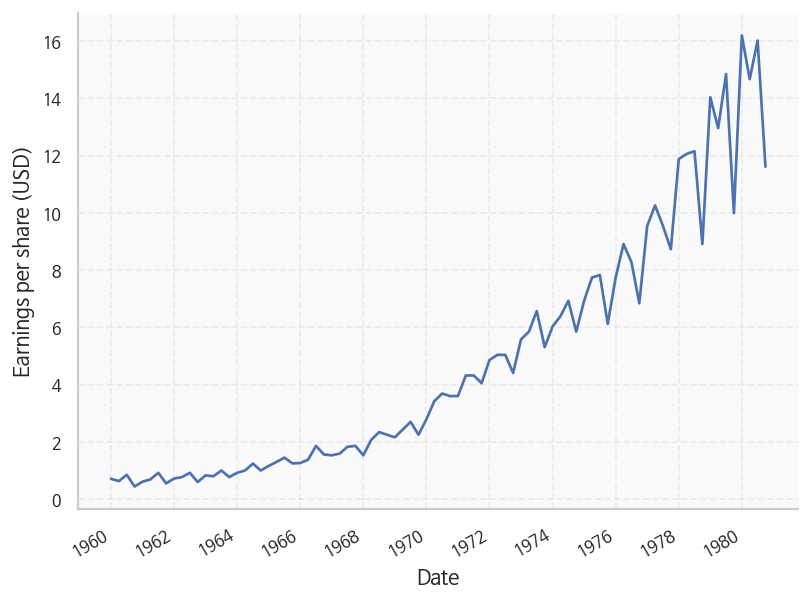

In [9]:
# 1. 그래프 도화지(Figure)와 축(Axis) 생성
fig, ax = plt.subplots()

# 2. 데이터 플로팅
# x축은 날짜(date), y축은 값(data)을 할당하여 선 그래프 생성
ax.plot(df.date, df.data)

# 3. 레이블 설정
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

# 4. x축 눈금(Ticks) 커스터마이징
# np.arange(0, 85, 8): 0부터 84까지 8 간격으로 눈금 위치 지정
# 그 위치에 대응하는 연도 리스트([1960, 1962, ...])를 라벨로 표시
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# 5. 날짜 라벨 자동 가독성 개선
# x축의 날짜 라벨이 길 경우 서로 겹치지 않도록 자동으로 기울여주는(기본 30~45도) 아주 유용한 함수입니다.
fig.autofmt_xdate()

# 6. 레이아웃 최적화
# 그래프의 여백을 자동으로 조정하여 축 레이블이 잘리지 않도록 배치합니다.
plt.tight_layout()

# 7. 출력
plt.show()

## 시계열 분해 및 시각화
- 시계열 분석의 꽃인 STL(Seasonal-Trend decomposition using LOESS) 기법을 사용하여 데이터를 4가지 성분으로 완벽하게 분리하고 시각화하는 과정입니다.
- STL 분해 결과 해석 가이드
  + Trend (추세): 데이터의 본질적인 방향성을 보여줍니다. 주식이나 실적 데이터라면 우상향하는지, 혹은 특정 시점부터 꺾이는지 파악할 수 있습니다.
  + Seasonal (계절성): 원본 데이터에서 파동처럼 보이던 부분이 분리된 것입니다. 값이 일정하다면 고정된 패턴이 있는 것이고, 진폭이 변한다면 계절적 영향력이 바뀌고 있음을 의미합니다.
  + Residuals (잔차): 이 그래프에서 갑자기 튀는 값(Spike)이 있다면, 그것은 단순한 계절성이나 추세로 설명할 수 없는 특이 사건(Event)이 발생했음을 시사합니다.

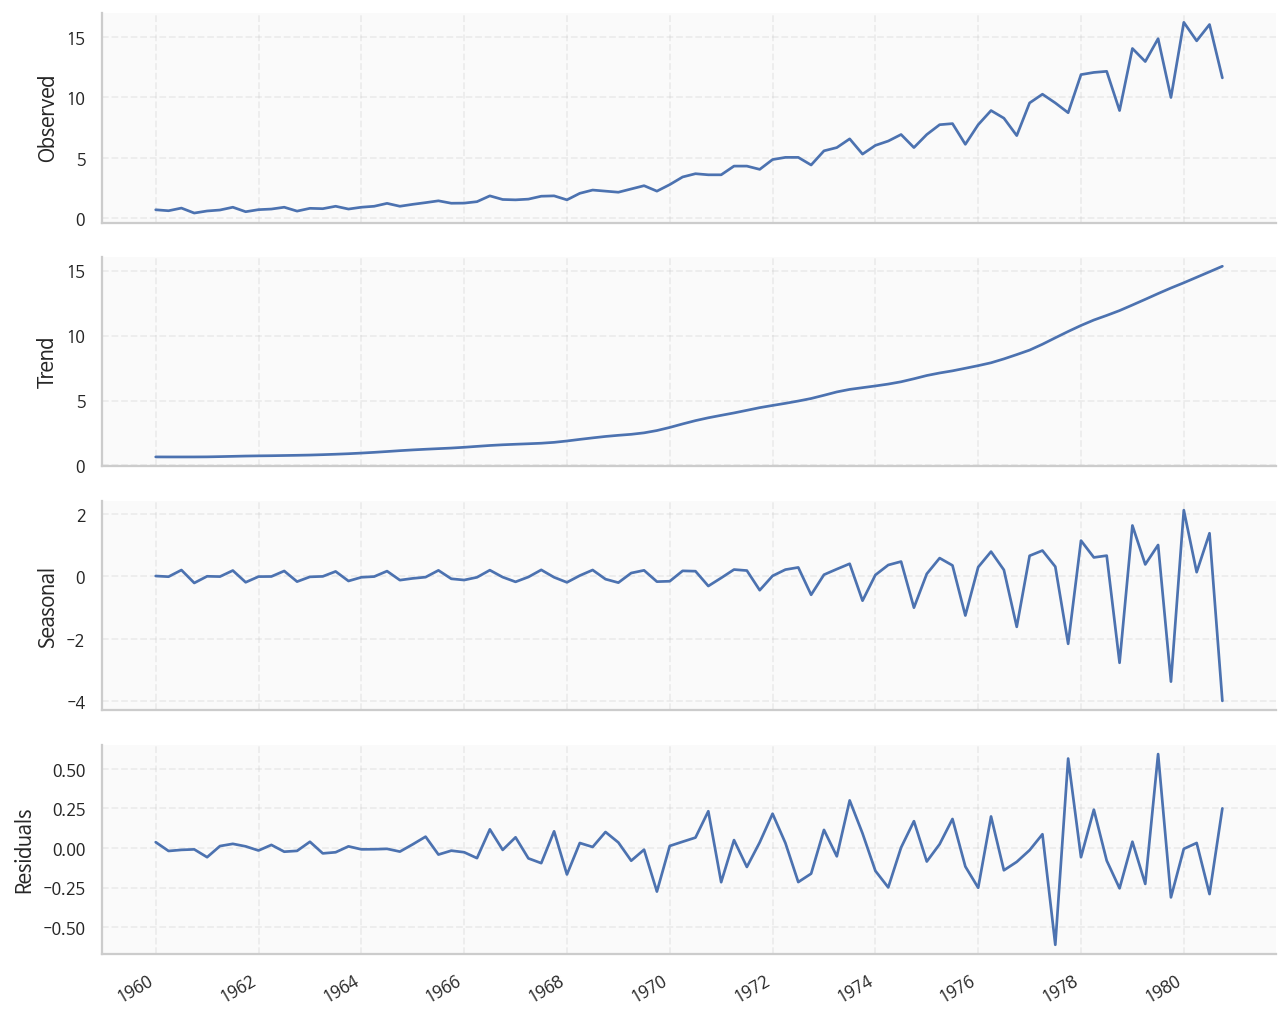

In [10]:
from pandas.core.arrays import period
# 1. STL 분해 실행
# period=4: 데이터의 계절성 주기 설정 (예: 분기별 데이터라면 4, 월별 데이터라면 12)
advanced_decomposition = STL(df.data, period=4).fit()

# 2. 4행 1열 구조의 서브플롯 생성
# sharex=True: 모든 그래프가 동일한 x축(날짜)을 공유하도록 설정하여 비교를 용이하게 함
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))

# 3. 각 성분별 시각화
# [Observed]: 원본 데이터 (추세 + 계절성 + 잔차의 합)
ax1.plot(advanced_decomposition.observed)
ax1.set_ylabel('Observed')

# [Trend]: 장기적인 상승 또는 하락 경향 (계절성과 노이즈가 제거된 매끄러운 곡선)
ax2.plot(advanced_decomposition.trend)
ax2.set_ylabel('Trend')

# [Seasonal]: 특정 주기마다 반복되는 패턴 (여기서는 period=4에 따른 분기 패턴)
ax3.plot(advanced_decomposition.seasonal)
ax3.set_ylabel('Seasonal')

# [Residuals]: 추세와 계절성으로 설명되지 않는 무작위 변동 (이상치 탐지에 활용)
ax4.plot(advanced_decomposition.resid)
ax4.set_ylabel('Residuals')

# 4. x축 눈금 및 라벨 설정 (이전 시각화와 동일하게 연도 매핑)
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# 5. 가독성 개선 및 레이아웃 조정
fig.autofmt_xdate() # 날짜 라벨 겹침 방지
plt.tight_layout() # 서브플롯 간 간격 자동 조정
plt.show()

## 데이터 복원
- 원래 상태로 복원

In [11]:
df = df.drop('year', axis=1)
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


# 베이스라인 모델 설계





## 예측구간 설정
- 훈련데이터 : 1960년부터 시작하여 1979년 말까지
- 예측데이터 : 1980년

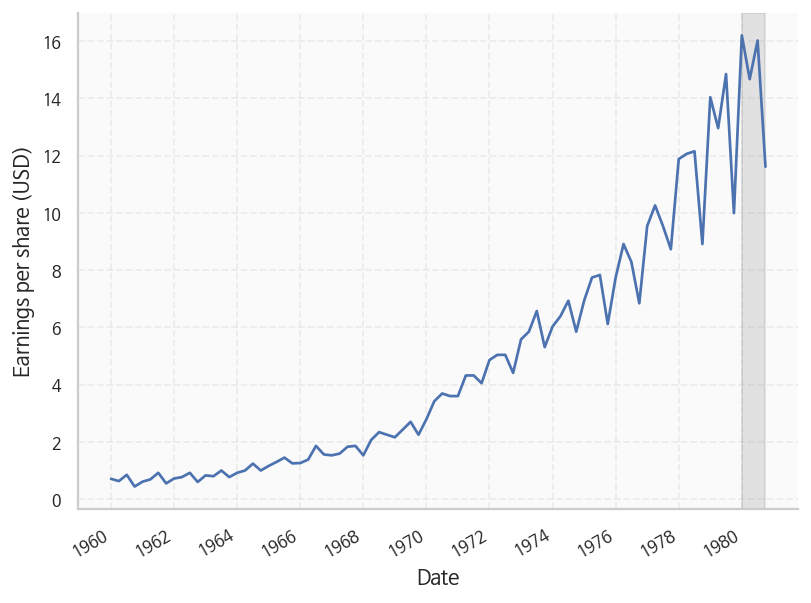

In [12]:
# 1. 그래프 도화지(Figure)와 축(Axis) 생성
fig, ax = plt.subplots()

# 2. 기본 시계열 선 그래프 출력
ax.plot(df['date'], df['data'])

# 3. 레이블 설정
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

# ---------------------------------------------------------
# 4. 특정 구간 음영 추가 (핵심 포인트)
# axvspan(start, end): x축의 시작점부터 끝점까지 수직으로 색을 채움
# - 80, 83: x축 인덱스 기준으로 80번부터 83번까지 강조
# - color='#808080': 회색(Gray) 계열 설정
# - alpha=0.2: 투명도 조절 (기존 선 그래프가 잘 보이도록 흐리게 설정)
# ---------------------------------------------------------
ax.axvspan(80, 83, color='#808080', alpha=0.2)

# 5. x축 눈금 설정 (0부터 80까지 8 간격으로 연도 매핑)
plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# 6. 날짜 라벨 자동 기울기 적용 (가독성 향상)
fig.autofmt_xdate()

# 7. 여백 최적화 및 출력
plt.tight_layout()
plt.show()

## 평가지표
- MAPE 함수 만들기
- 단점 (Zero Division): 실제값(y_true) 중에 0이 포함되어 있으면 계산 결과가 무한대(inf)가 되거나 에러가 발생합니다. (이럴 때는 분모에 아주 작은 값을 더하거나 SMAPE 같은 대안 지표를 사용합니다.)

In [13]:
def mape(y_true, y_pred):
    """
    모델의 예측 오차를 백분율(%)로 반환하는 함수

    Args:
        y_true: 실제값 (Numpy array 또는 Pandas Series)
        y_pred: 모델의 예측값 (Numpy array 또는 Pandas Series)
    """
    # 1. (y_true - y_pred) / y_true: 실제값 대비 오차의 비율 계산
    # 2. np.abs(...): 오차가 양수든 음수든 크기만을 고려하기 위해 절대값 취함
    # 3. np.mean(...): 모든 데이터 포인트에 대한 오차 비율의 평균 계산
    # 4. * 100: 소수점 형태의 오차율을 백분율(%) 단위로 변환
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## 데이터셋 분리

In [14]:
train = df[:-4]
test = df[-4:]

## 모델 1 (지난 19년도 데이터)


In [15]:
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [16]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [17]:
# 모델 학습
historical_mean = np.mean(train['data'])
historical_mean

np.float64(4.308499987499999)

In [18]:
# 모델 예측
test.loc[:, 'pred_mean'] = historical_mean
test

/tmp/ipykernel_1103/2027648825.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_mean'] = historical_mean


,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


In [23]:
# 평가지표 산출
mape_hist_mean = mape(test['data'], test['pred_mean'])
mape_hist_mean  # 약 70% 차이 발생

np.float64(70.00752579965119)

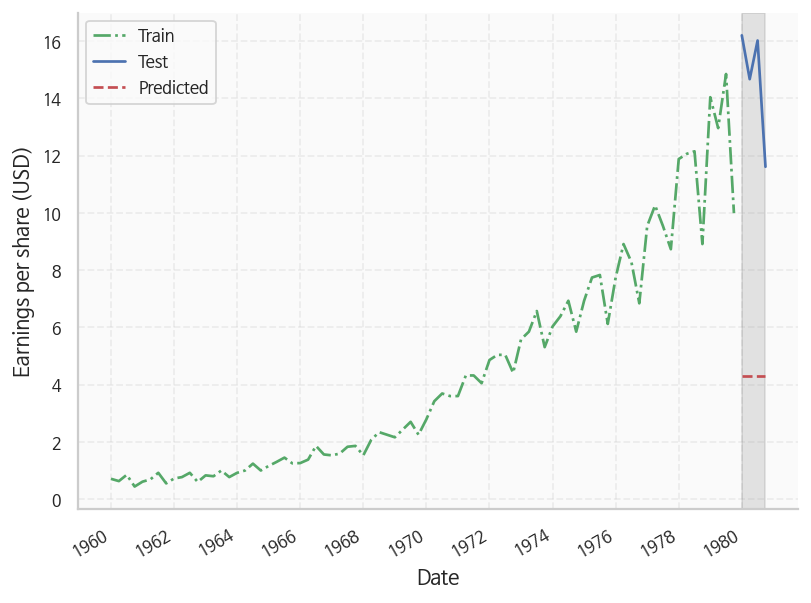

In [24]:
# 1. 그래프 도화지(Figure)와 축(Axis) 생성
fig, ax = plt.subplots()

# 2. 데이터별 선 그래프 출력 (스타일 차별화)
# 'g-.': 초록색(green) 점쇄선으로 학습 데이터 표시
ax.plot(train['date'], train['data'], 'g-.', label='Train')

# 'b-': 파란색(blue) 실선으로 실제 테스트 데이터(정답) 표시
ax.plot(test['date'], test['data'], 'b-', label='Test')

# 'r--': 빨간색(red) 점선으로 모델이 예측한 평균값 표시
ax.plot(test['date'], test['pred_mean'], 'r--', label='Predicted')

# 3. 레이블 및 구간 강조
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

# 예측 구간(80~83)을 시각적으로 돋보이게 회색 음영 처리
ax.axvspan(80, 83, color='#808080', alpha=0.2)

# 4. 범례(Legend) 설정
# loc=2: 범례 위치를 '좌측 상단(Upper Left)'으로 지정
ax.legend(loc=2)

# 5. x축 눈금 설정 (연도 매핑)
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# 6. 가독성 개선 및 레이아웃 최적화
fig.autofmt_xdate() # 날짜 겹침 방지
plt.tight_layout() # 여백 조정
plt.show()

## 모델 2 (작년 1년 데이터)

In [25]:
# 1. 최근 1년(4분기) 데이터의 평균 계산
# train['data'][-4:]: 학습 데이터의 가장 마지막 4개 데이터(1년치) 슬라이싱
# np.mean(...): 슬라이싱된 4개 값의 산술 평균을 구함
last_year_mean = np.mean(train['data'][-4:])

# 2. 테스트 데이터에 예측값 할당
# test.loc[:, 'pred_last_yr_mean']: 테스트 데이터프레임에 새로운 컬럼 생성
# 모든 행에 위에서 계산한 동일한 평균값(last_year_mean)을 채워 넣음 (수평선 예측)
test.loc[:, 'pred_last_yr_mean'] = last_year_mean

# 3. 결과 상단 확인
# 데이터가 의도한 대로 채워졌는지 처음 5개의 행을 출력
test.head()

/tmp/ipykernel_1103/552056618.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_last_yr_mean'] = last_year_mean


,date,data,pred_mean,pred_last_yr_mean
80,1980-01-01,16.20,4.3085,12.96
81,1980-04-01,14.67,4.3085,12.96
82,1980-07-02,16.02,4.3085,12.96
83,1980-10-01,11.61,4.3085,12.96


In [27]:
mape_last_year_mean = mape(test['data'], test['pred_last_yr_mean'])

mape_last_year_mean # 결과 출력 약 15.6% 오차가 확인됨

np.float64(15.5963680725103)

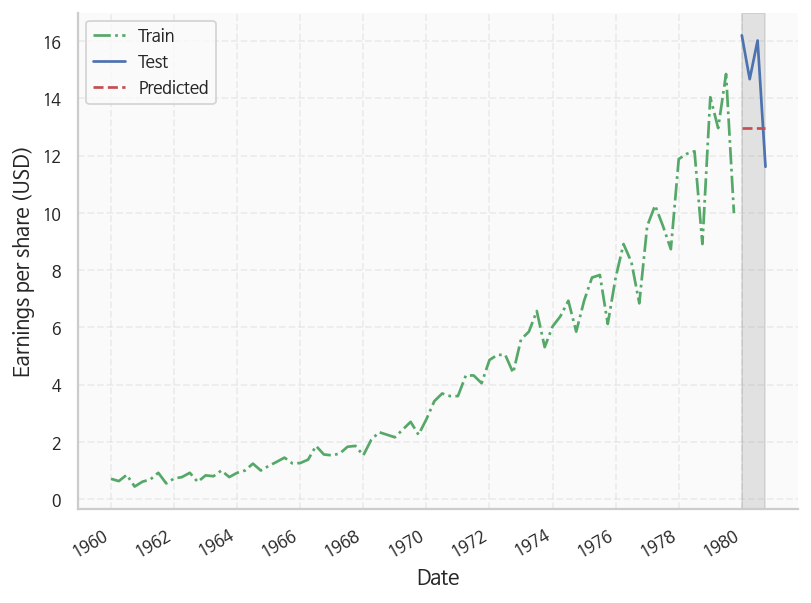

In [28]:
# 1. 그래프 도화지(Figure)와 축(Axis) 생성
fig, ax = plt.subplots()

# 2. 데이터별 선 그래프 출력 (스타일 차별화)
# 'g-.': 초록색 점쇄선으로 과거 학습 데이터(Train) 표시
ax.plot(train['date'], train['data'], 'g-.', label='Train')

# 'b-': 파란색 실선으로 실제 발생한 정답 데이터(Test) 표시
ax.plot(test['date'], test['data'], 'b-', label='Test')

# 'r--': 빨간색 점선으로 '직전 1년 평균' 예측값 표시 (일반적으로 수평선 형태)
ax.plot(test['date'], test['pred_last_yr_mean'], 'r--', label='Predicted')

# 3. 축 레이블 및 강조 구간 설정
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

# 테스트 데이터가 존재하는 구간(인덱스 80~83)에 회색 음영 추가
ax.axvspan(80, 83, color='#808080', alpha=0.2)

# 4. 범례 표시 (loc=2: 좌측 상단)
ax.legend(loc=2)

# 5. x축 눈금 설정 (연도 매핑)
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# 6. 날짜 라벨 자동 기울기 적용 및 레이아웃 최적화
fig.autofmt_xdate()
plt.tight_layout()

# 7. 그래프 출력
plt.show()

## 모델 1과 2 비교

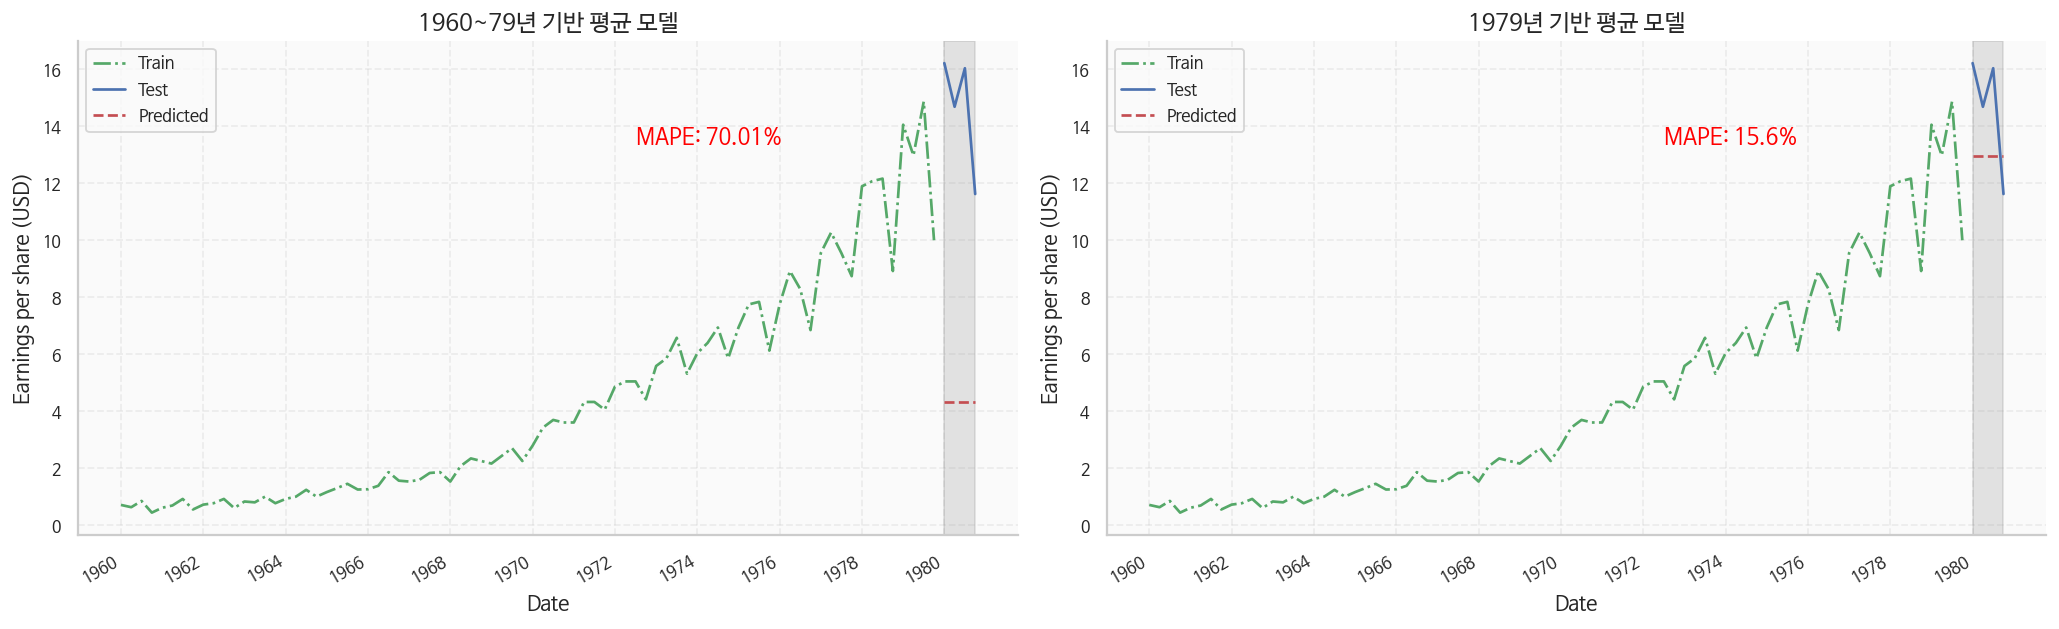

In [29]:
# 1. 1행 2열(ncols=2) 구조의 서브플롯 생성
fig, ax = plt.subplots(ncols=2, figsize=(16, 5))

# ---------------------------------------------------------
# [왼쪽 그래프]: 전체 기간(1960~1979) 평균 기반 모델
# ---------------------------------------------------------
ax[0].plot(train['date'], train['data'], 'g-.', label='Train')
ax[0].plot(test['date'], test['data'], 'b-', label='Test')
ax[0].plot(test['date'], test['pred_mean'], 'r--', label='Predicted')
ax[0].set_title('1960~79년 기반 평균 모델')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Earnings per share (USD)')
ax[0].axvspan(80, 83, color='#808080', alpha=0.2)
ax[0].legend(loc=2)
# 축 눈금 설정
ax[0].set_xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
# 그래프 내부에 MAPE 수치 텍스트 표시 (시각적 피드백)
ax[0].text(50, max(train['data']) * 0.9, f"MAPE: {round(mape_hist_mean, 2)}%", color='red', fontsize=12)

# ---------------------------------------------------------
# [오른쪽 그래프]: 최근 1년(1979) 평균 기반 모델
# ---------------------------------------------------------
ax[1].plot(train['date'], train['data'], 'g-.', label='Train')
ax[1].plot(test['date'], test['data'], 'b-', label='Test')
ax[1].plot(test['date'], test['pred_last_yr_mean'], 'r--', label='Predicted')
ax[1].set_title('1979년 기반 평균 모델')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Earnings per share (USD)')
ax[1].axvspan(80, 83, color='#808080', alpha=0.2)
ax[1].legend(loc=2)
# 축 눈금 설정
ax[1].set_xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
# 그래프 내부에 MAPE 수치 텍스트 표시
ax[1].text(50, max(train['data']) * 0.9, f"MAPE: {round(mape_last_year_mean, 2)}%", color='red', fontsize=12)

# 2. 공통 서식 설정 및 파일 저장
fig.autofmt_xdate()    # 날짜 라벨 겹침 방지
plt.tight_layout()     # 여백 자동 조정
plt.savefig('earnings_per_share_forecast.png')  # 그래프를 이미지 파일로 저장
plt.show()

## 계절적 예측 구현
- 주기적 패턴 확인

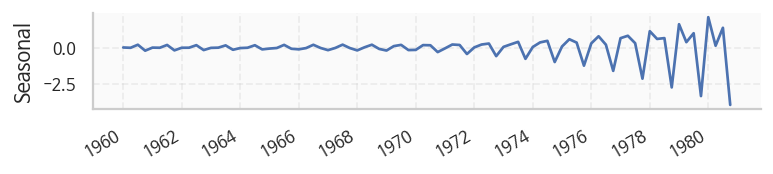

In [30]:
# 1. 가로로 긴 형태의 그래프 도화지 생성
# figsize=(6, 1.5): 계절성 패턴의 반복성을 잘 보여주기 위해 높이를 낮게 설정함
fig, ax = plt.subplots(figsize=(6, 1.5))

# 2. STL 분해 결과에서 계절성(Seasonal) 데이터만 추출하여 플로팅
# advanced_decomposition.seasonal: 원본에서 추세와 잔차를 제외한 반복 패턴
ax.plot(advanced_decomposition.seasonal)
ax.set_ylabel('Seasonal')

# 3. x축 눈금 설정 (1960년부터 1980년까지 2년 단위 매핑)
# np.arange(0, 85, 8): 인덱스 0부터 8 간격으로 눈금 위치 지정
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# 4. 날짜 라벨 자동 최적화 (기울기 적용)
fig.autofmt_xdate()

# 5. 그래프 여백 자동 조정 및 출력
plt.tight_layout()
plt.show()

- 단순한 계절적 예측 방법
  + 마지막으로 측정된 주기가 미래에도 반복된다는 것
  + 1979년 첫 번째 분기의 EPS를 사용하여 1980년 첫 번째 분기의 값 예측
- 측정결과 가장 낮은 MAPE 기록 (11.56%)

In [32]:
# 1. 직전 주기(1년 = 4분기)의 실제 값을 미래 예측 값으로 복사
# - 계절성을 그대로 복사한다
test.loc[:, 'pred_last_season'] = train['data'][-4:].values
mape_naive_seasonal = mape(test['data'], test['pred_last_season'])

# 결과 확인
mape_naive_seasonal

/tmp/ipykernel_1103/2649470117.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_last_season'] = train['data'][-4:].values


np.float64(11.561658552433654)

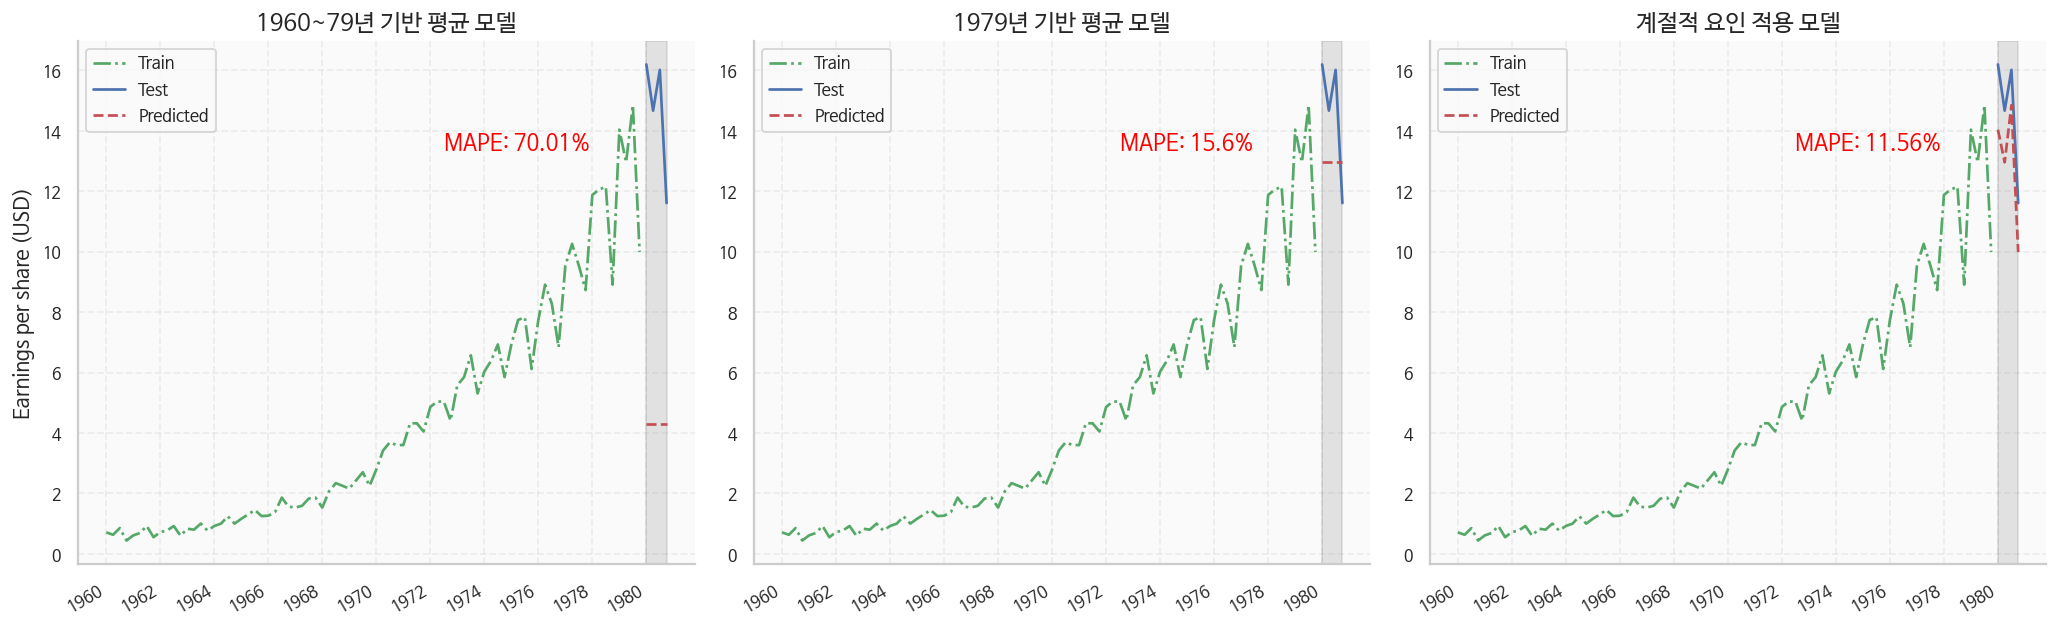

In [33]:
# 1. 1행 3열(ncols=3) 구조의 서브플롯 생성
# 세 가지 모델의 결과를 동일한 스케일에서 비교하기 위해 넓은 figsize 설정
fig, ax = plt.subplots(ncols=3, figsize=(16, 5))

# ---------------------------------------------------------
# [왼쪽 - ax[0]]: 전체 역사적 평균 모델 (1960~79)
# 가장 단순한 형태이며, 데이터의 장기적 상승 추세를 전혀 반영하지 못함
# ---------------------------------------------------------
ax[0].plot(train['date'], train['data'], 'g-.', label='Train')
ax[0].plot(test['date'], test['data'], 'b-', label='Test')
ax[0].plot(test['date'], test['pred_mean'], 'r--', label='Predicted')
ax[0].set_title('1960~79년 기반 평균 모델')
ax[0].set_ylabel('Earnings per share (USD)')
ax[0].axvspan(80, 83, color='#808080', alpha=0.2)
ax[0].legend(loc=2)
ax[0].set_xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
ax[0].text(50, max(train['data']) * 0.9, f"MAPE: {round(mape_hist_mean, 2)}%", color='red', fontsize=12)

# ---------------------------------------------------------
# [중앙 - ax[1]]: 최근 1년 평균 모델 (1979)
# 전체 평균보다는 낫지만, 분기별로 오르내리는 '계절적 패턴'은 무시함 (수평선 예측)
# ---------------------------------------------------------
ax[1].plot(train['date'], train['data'], 'g-.', label='Train')
ax[1].plot(test['date'], test['data'], 'b-', label='Test')
ax[1].plot(test['date'], test['pred_last_yr_mean'], 'r--', label='Predicted')
ax[1].set_title('1979년 기반 평균 모델')
ax[1].axvspan(80, 83, color='#808080', alpha=0.2)
ax[1].legend(loc=2)
ax[1].set_xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
ax[1].text(50, max(train['data']) * 0.9, f"MAPE: {round(mape_last_year_mean, 2)}%", color='red', fontsize=12)

# ---------------------------------------------------------
# [오른쪽 - ax[2]]: 계절적 요인 적용 모델 (Seasonal Naive)
# 작년 동기의 값을 그대로 사용함. 수평선이 아닌 '지그재그' 패턴이 나타남
# ---------------------------------------------------------
ax[2].plot(train['date'], train['data'], 'g-.', label='Train')
ax[2].plot(test['date'], test['data'], 'b-', label='Test')
ax[2].plot(test['date'], test['pred_last_season'], 'r--', label='Predicted')
ax[2].set_title('계절적 요인 적용 모델')
ax[2].axvspan(80, 83, color='#808080', alpha=0.2)
ax[2].legend(loc=2)
ax[2].set_xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
# 세 모델 중 가장 낮은 MAPE를 기록할 가능성이 높음
ax[2].text(50, max(train['data']) * 0.9, f"MAPE: {round(mape_naive_seasonal, 2)}%", color='red', fontsize=12)

# 2. 서식 최적화 및 이미지 저장
fig.autofmt_xdate()    # 날짜 라벨 자동 기울기
plt.tight_layout()     # 플롯 간 간격 조정
plt.savefig('earnings_per_share_forecast.png') # 최종 비교 결과 저장
plt.show()

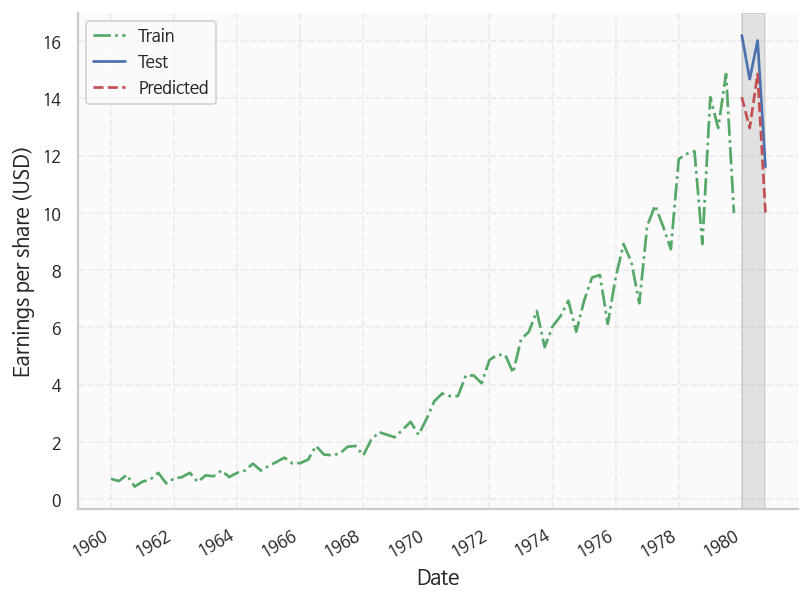

In [34]:
# 1. 그래프 도화지(Figure)와 축(Axis) 생성
fig, ax = plt.subplots()

# 2. 데이터별 선 그래프 출력 (색상과 선 스타일로 구분)
# 'g-.': 학습 데이터(Train) - 초록색 점쇄선
ax.plot(train['date'], train['data'], 'g-.', label='Train')

# 'b-': 실제 정답 데이터(Test) - 파란색 실선
ax.plot(test['date'], test['data'], 'b-', label='Test')

# 'r--': 계절성 나이브 예측값(Predicted) - 빨간색 점선
# 작년 동기(4분기 전)의 값을 그대로 가져왔으므로 실제 데이터와 유사한 굴곡이 나타남
ax.plot(test['date'], test['pred_last_season'], 'r--', label='Predicted')

# 3. 축 레이블 설정
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

# 4. 예측 구간 강조 (음영 처리)
# 인덱스 80~83 구간(테스트 데이터 구간)을 회색 배경으로 강조
ax.axvspan(80, 83, color='#808080', alpha=0.2)

# 5. 범례 표시 (loc=2: 좌측 상단)
ax.legend(loc=2)

# 6. x축 눈금 설정 (연도 매핑)
# 8 간격(2년 주기에 해당)으로 눈금을 배치하고 해당 연도를 라벨로 부착
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

# 7. 날짜 라벨 가독성 최적화 및 레이아웃 조정
fig.autofmt_xdate() # 날짜가 겹치지 않게 자동으로 기울임
plt.tight_layout()  # 그래프 구성 요소들이 잘리지 않게 조정

# 8. 최종 출력
plt.show()

## 각 모델 성능 비교

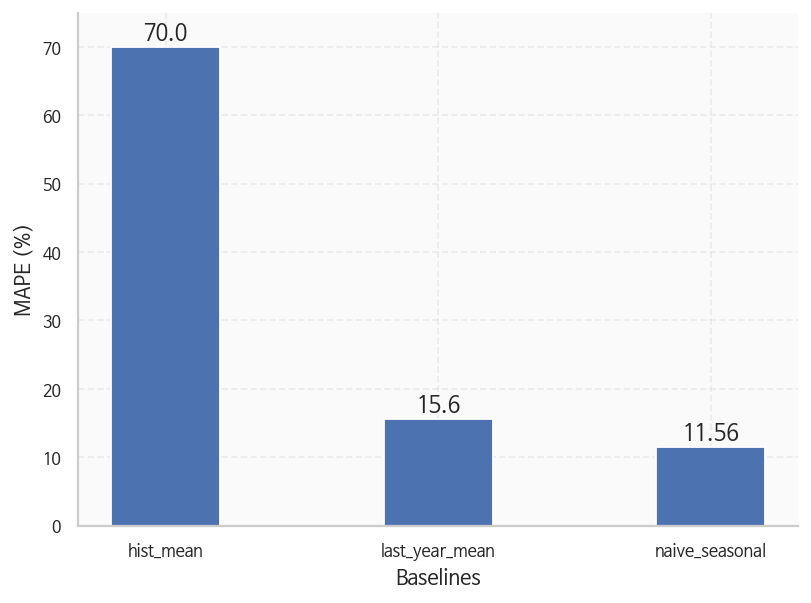

In [35]:
fig, ax = plt.subplots()

x = ['hist_mean', 'last_year_mean', 'naive_seasonal']
y = [70.00, 15.60, 11.56]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Baselines')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 75)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(value), ha='center')

plt.tight_layout()

# 확률보행 따라가보기
- "어제와 오늘의 연결" (자기상관)
  + 확률보행에서 오늘의 값($y_t$)은 어제의 값($y_{t-1}$)에 무작위 오차($\epsilon_t$)를 더해서 결정됩니다.
$$y_t = y_{t-1} + \epsilon_t$$
  + 즉, 현재 위치는 바로 이전 위치에서 시작하며, 어디로 튈지는 오직 '확률'에 맡깁니다.
- 예측 불가능성 (Efficiency)
  + 다음 단계가 오를지 내릴지는 순전히 무작위 오차($\epsilon_t$)에 달려 있습니다.
  + 이 오차는 보통 평균이 0인 정규분포를 따른다고 가정
  + "내일의 가장 좋은 예측치는 오늘이다"라는 결론에 도달하게 됩니다.
- 비정상성 (Non-stationary)
  + 확률보행 데이터는 시간이 지날수록 평균에서 멀어지거나 변동폭이 커지는 경향이 있습니다.
  + 즉, 일정한 평균값으로 회귀하려는 성질이 없기 때문에 통계적으로 '불안정한' 데이터입니다.

## 데이터 불러오기

In [36]:
df = pd.read_csv(DATA_PATH + 'GOOGL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


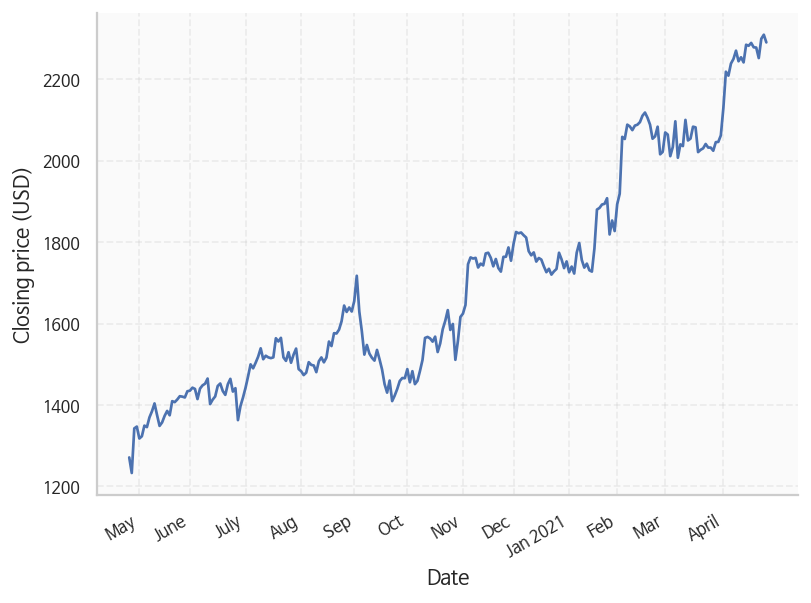

In [37]:
fig, ax = plt.subplots()

ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235],
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## 확률보행 시각화

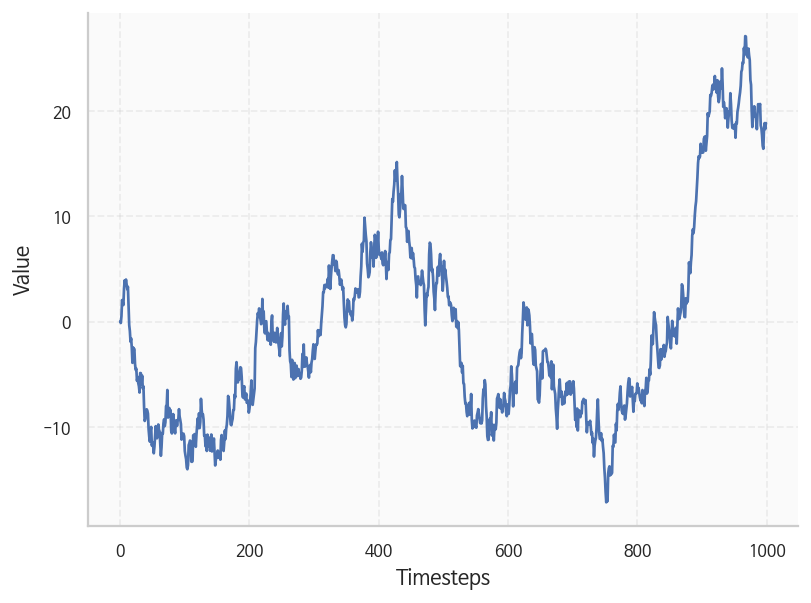

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 재현성을 위한 랜덤 시드 고정
# 동일한 시드 번호(42)를 사용하면 실행할 때마다 같은 무작위 결과가 나옵니다.
np.random.seed(42)

# 2. 무작위 단계(Steps) 생성
# np.random.standard_normal(1000): 평균 0, 표준편차 1인 표준정규분포에서 1000개의 난수 생성
steps = np.random.standard_normal(1000)

# 시작점 설정: 첫 번째 위치를 0으로 고정하여 원점에서 시작하게 함
steps[0] = 0

# 3. 확률보행 데이터 생성 (누적 합계)
# np.cumsum(steps): 이전 단계의 모든 값을 더해 나가는 방식
# 오늘 값 = 어제 값 + 오늘 발생한 무작위 오차(step)
random_walk = np.cumsum(steps)

# 4. 시각화 설정
fig, ax = plt.subplots()

# 생성된 확률보행 데이터를 선 그래프로 출력
ax.plot(random_walk)

# 축 레이블 설정
ax.set_xlabel('Timesteps')  # 시간의 흐름 (단계)
ax.set_ylabel('Value')      # 해당 시점의 누적 가치

# 그래프 여백 자동 최적화 및 출력
plt.tight_layout()
plt.show()

## 정상성 테스트

### 정상 vs 비정상 시계열 시각화
- $\alpha = 0.5$ (정상성)
  + 값이 일시적으로 튀더라도 다음 단계에서 절반($0.5$)으로 줄어듭니다.
  + 따라서 시간이 지나도 일정한 평균(0 근처) 주위에서 머무는 평균 회귀(Mean Reversion) 특성을 보입니다.
- $\alpha = 1.0$ (비정상성)
  + 이전의 모든 충격(노이즈)이 그대로 다음 단계로 전달됩니다.
  + 이것이 바로 확률보행(Random Walk)이며, 데이터가 정해진 평균 없이 정처 없이 떠돌게 됩니다.

In [39]:
def simulate_process(is_stationary: bool) -> np.array:
    """
    정상성 또는 비정상성 시계열 데이터를 생성하는 함수

    Args:
        is_stationary: True이면 정상성(AR(1)), False이면 비정상성(Random Walk) 생성
    """
    np.random.seed(42)       # 결과 재현을 위한 시드 고정
    process = np.empty(400)  # 400개의 데이터를 담을 빈 배열 생성

    if is_stationary:
        # 1. 정상성 프로세스 (Stationary)
        # alpha < 1 이면 값이 커지더라도 결국 평균으로 회귀함
        alpha = 0.5
        process[0] = 0
    else:
        # 2. 비정상성 프로세스 (Non-stationary / Random Walk)
        # alpha = 1 이면 이전의 오차가 누적되어 평균에서 계속 멀어짐
        alpha = 1
        process[0] = 10      # 시작점을 10으로 설정 (임의)

    # 시계열 생성 루프 (AR(1) 모델 구조: y_t = alpha * y_{t-1} + noise)
    for i in range(400):
        if i + 1 < 400:
            # 현재 값에 alpha를 곱하고 정규분포 노이즈를 더해 다음 값을 결정
            process[i+1] = alpha * process[i] + np.random.standard_normal()
        else:
            break

    return process

In [41]:
stationary = simulate_process(True)
non_stationary = simulate_process(False)

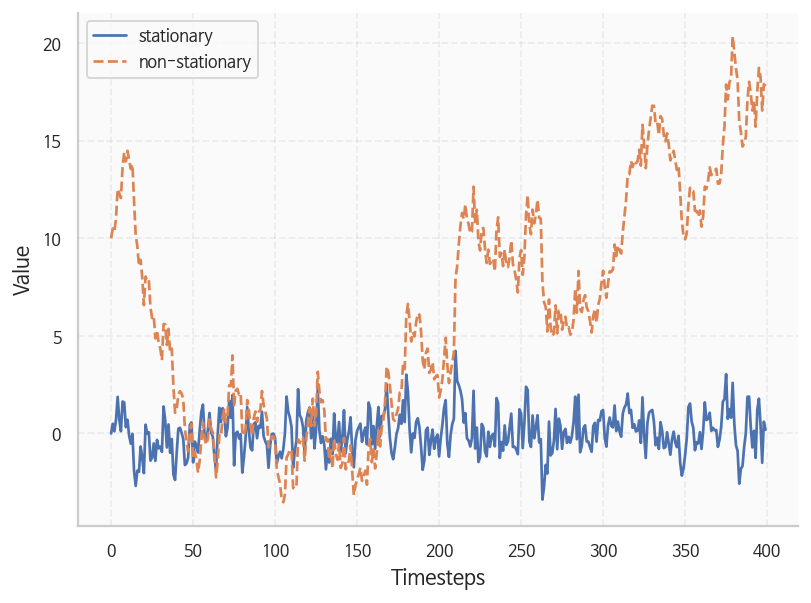

In [42]:
# 1. 그래프 도화지(Figure)와 축(Axis) 객체 생성
fig, ax = plt.subplots()

# 2. 정상성(Stationary) 데이터 플로팅
# linestyle='-': 실선으로 표시하여 평균으로 회귀하는 안정적인 흐름을 강조
ax.plot(stationary, linestyle='-', label='stationary')

# 3. 비정상성(Non-stationary) 데이터 플로팅
# linestyle='--': 점선으로 표시하여 정처 없이 떠도는(Random Walk) 특성을 시각적으로 구분
ax.plot(non_stationary, linestyle='--', label='non-stationary')

# 4. 축 레이블 설정
ax.set_xlabel('Timesteps')  # 시간의 흐름 (단계)
ax.set_ylabel('Value')      # 관측값

# 5. 범례(Legend) 표시
# loc=2: 범례를 '좌측 상단(Upper Left)'에 배치하여 데이터 선과 겹침을 최소화
ax.legend(loc=2)

# 6. 레이아웃 최적화 및 그래프 출력
# tight_layout(): 축 레이블이나 제목이 잘리지 않도록 여백을 자동으로 조정
plt.tight_layout()
plt.show()

### 평균이 일정한가?

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


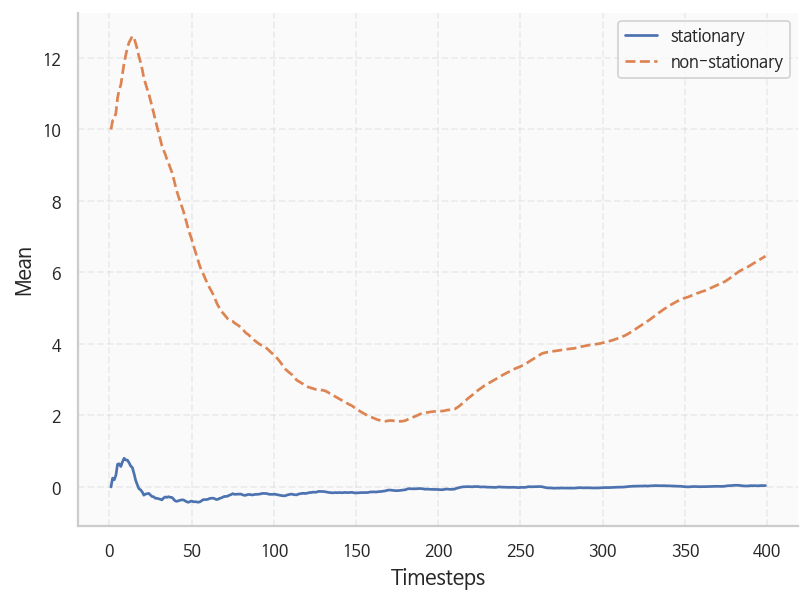

In [43]:
def mean_over_time(process: np.array) -> np.array:
    mean_func = []

    for i in range(len(process)):
        mean_func.append(np.mean(process[:i]))

    return mean_func

stationary_mean = mean_over_time(stationary)
non_stationary_mean = mean_over_time(non_stationary)

fig, ax = plt.subplots()

ax.plot(stationary_mean, label='stationary')
ax.plot(non_stationary_mean, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Mean')
ax.legend(loc=1)

plt.tight_layout()
plt.show()

### 분산이 일정한가?

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


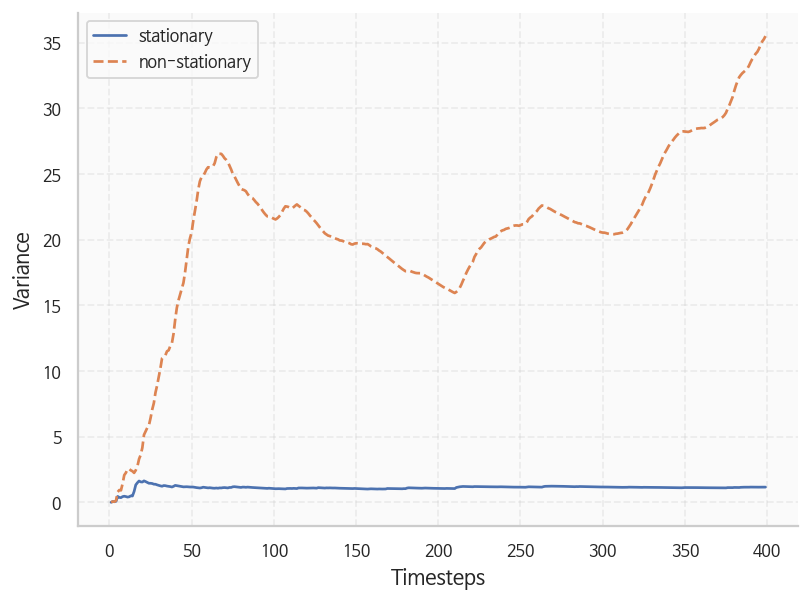

In [44]:
def var_over_time(process: np.array) -> np.array:
    var_func = []

    for i in range(len(process)):
        var_func.append(np.var(process[:i]))

    return var_func

stationary_var = var_over_time(stationary)
non_stationary_var = var_over_time(non_stationary)

fig, ax = plt.subplots()

ax.plot(stationary_var, label='stationary')
ax.plot(non_stationary_var, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Variance')
ax.legend(loc=2)

plt.tight_layout()
plt.show()

### 3개 그래프 합치기

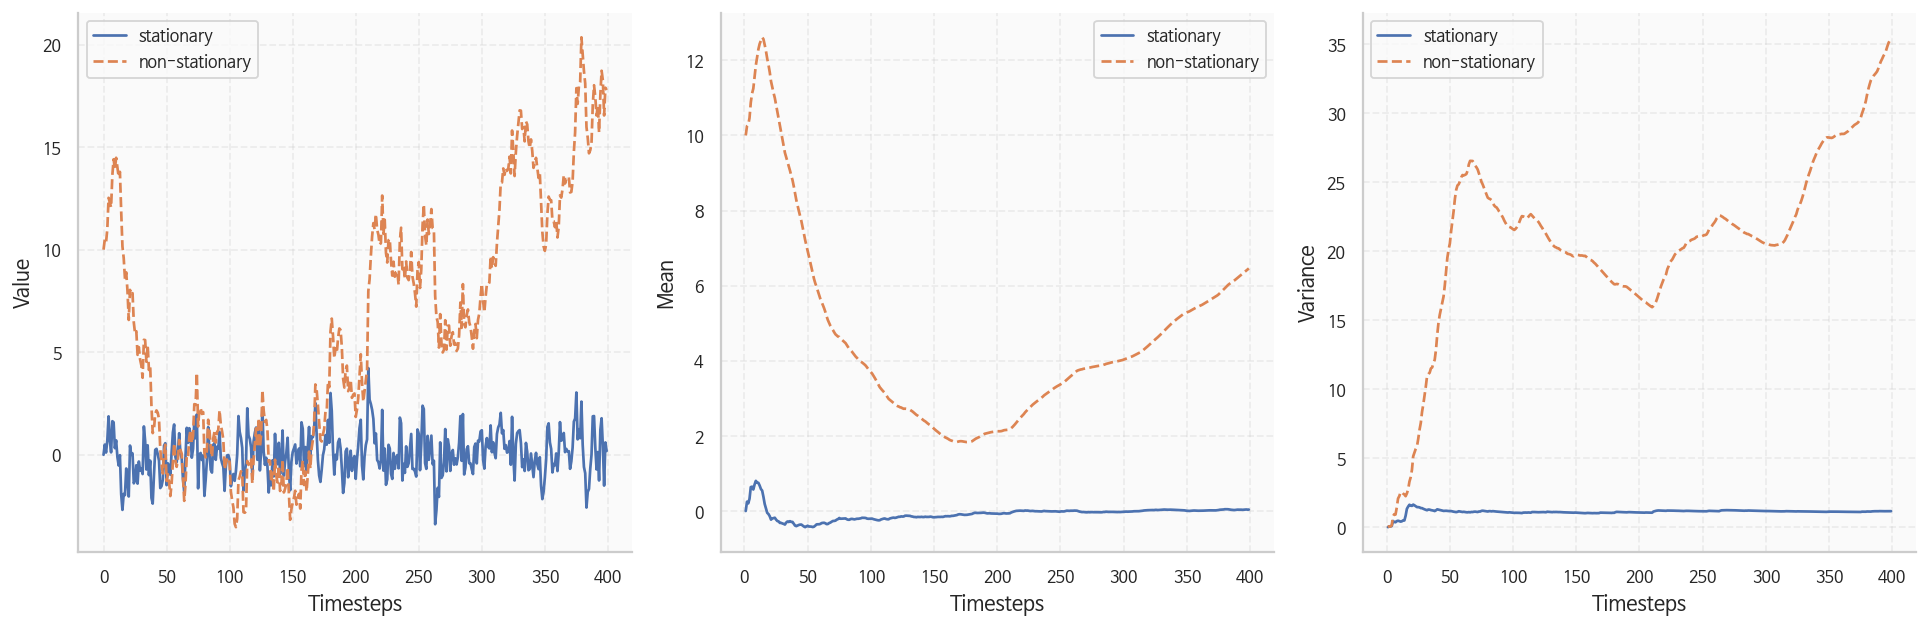

In [45]:
fig, ax = plt.subplots(ncols = 3, figsize=(15, 5))

ax[0].plot(stationary, linestyle='-', label='stationary')
ax[0].plot(non_stationary, linestyle='--', label='non-stationary')
ax[0].set_xlabel('Timesteps')
ax[0].set_ylabel('Value')
ax[0].legend(loc=2)

ax[1].plot(stationary_mean, label='stationary')
ax[1].plot(non_stationary_mean, linestyle='--', label='non-stationary')
ax[1].set_xlabel('Timesteps')
ax[1].set_ylabel('Mean')
ax[1].legend(loc=1)

ax[2].plot(stationary_var, label='stationary')
ax[2].plot(non_stationary_var, linestyle='--', label='non-stationary')
ax[2].set_xlabel('Timesteps')
ax[2].set_ylabel('Variance')
ax[2].legend(loc=2)

plt.tight_layout()
plt.show()

# 자기상관관계

### 확률보행 확인
- ADF(Augmented Dickery-Fuller Test) 테스트 적용
  - ADF 테스트 적용
    + 귀무가설 : 주어진 시계열 데이터는 비정상 시계열이다(=정상성이 아니다)
    + 대립가설 : 주어진 시계열 데이터는 비정상 시계열이 아니다(=정상성이다)
  - 시계열 검정 진행 절차는 1차적으로 ADF 가설 검정을 만족해야 한다(귀무가설 기각 => 대립가설 채택)

In [69]:
from statsmodels.tsa.stattools import adfuller

# 검정
ADF_result = adfuller(random_walk)
print(f'ADF Statistic: {ADF_result[0]}')

# p-value 확인
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -0.965952487691875
p-value: 0.7654789696692581


#### 자기상관함수(ACF, Autocorrelation Function) 시각화

- 현재 데이터가 과거의 데이터와 얼마나 강한 패턴을 공유하고 있는지(자기상관성)를 직관적으로 보여줍니다.
- 그래프를 실행하시면 위와 같이 가로축은 시차(Lag), 세로축은 상관계수(-1.0 ~ 1.0)를 나타내는 막대 그래프(Correlogram)가 출력될 것입니다.
- 이 그래프에서 주목해야 할 세 가지 핵심 포인트는 다음과 같습니다.
  이해하기 쉽도록 핵심 내용만 추려 단일 수준의 불릿 포인트(Bullet point)로 간결하게 정리해 드립니다.
  + **비정상성의 느린 감소(Slow Decay):** $y_t = y_{t-1} + \epsilon_t$ 구조로 인해 과거의 기억이 오래 유지되므로, 시차가 커져도 ACF 막대가 천천히 감소합니다. (반면, 정상성 데이터는 급격히 0으로 떨어집니다.)
  + **시차 0 (Lag 0)의 의미:** 현재 시점($y_t$) 자기 자신과의 상관관계를 의미하므로 첫 번째 막대는 항상 **1.0**입니다.
  + **95% 신뢰구간 (파란색 음영):** 막대가 이 영역을 **벗어나면** '통계적으로 유의미한 상관관계가 있음'을, 영역 **안에 있으면** '상관관계가 없음'을 뜻합니다. (랜덤 워크는 시차 20에서도 영역을 벗어나는 경우가 많습니다.)

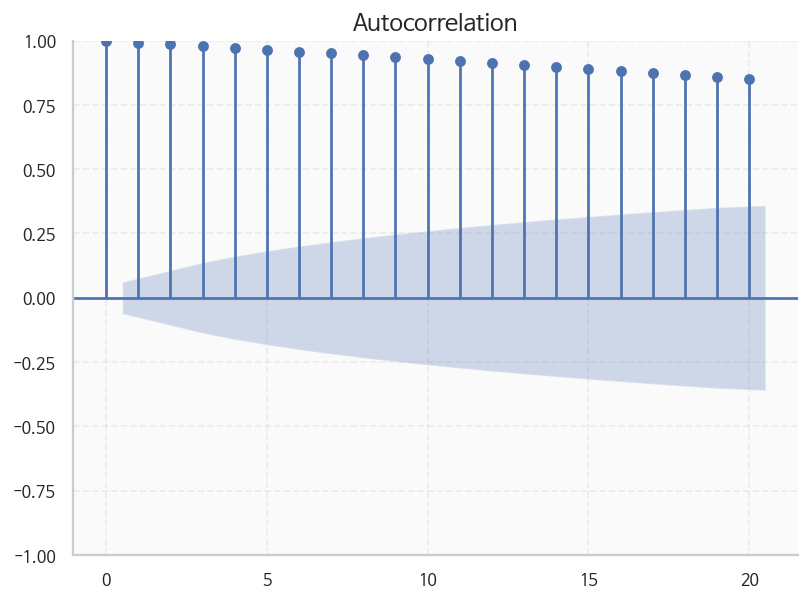

In [70]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(random_walk, lags=20)

plt.tight_layout()
plt.show()

## 차분진행 후 시각화

- 비정상성 시계열이 가진 문제(일정하지 않은 평균과 발산하는 분산)를 해결하기 위해, 시계열 분석의 가장 핵심적인 전처리 기법인 차분(Differencing)을 적용
- **차분의 원리:** 수식 $y_t - y_{t-1} = \epsilon_t$ 를 적용하여, 비정상성 데이터를 평균과 분산이 일정한 순수 백색 잡음(White Noise)으로 변환합니다.
- **정상성 시각화:** 차분 후의 그래프는 더 이상 발산하거나 표류하지 않고, 0을 중심으로 일정하게 진동하는 정상성(Stationary) 패턴을 보입니다.
- **적분 차수(Order of Integration):** 1번 차분하여 정상성을 띠는 원본 데이터를 **I(1)** 과정, 차분이 완료되어 정상성을 획득한 상태를 **I(0)** 과정이라 하며, 이는 ARIMA 모델 적용을 위한 필수 조건입니다.


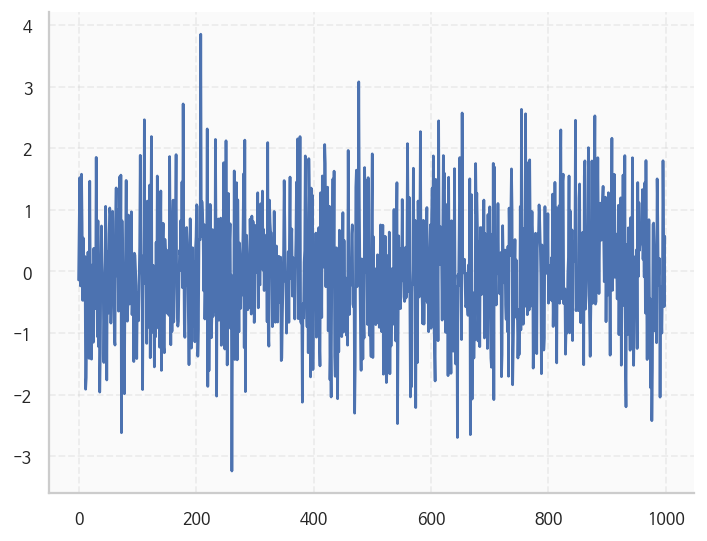

In [71]:
import numpy as np

# 1차 차분
# 현재 시점의 값에서 바로 이전 시점의 값을 빼는 작업
diff_random_walk = np.diff(random_walk, n=1)

# 시각화 부분
plt.plot(diff_random_walk)

In [72]:
ADF_result = adfuller(diff_random_walk)

print(f'ADF Statistic: {ADF_result[0]}')

# p-value 확인
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -31.789310857560594
p-value: 0.0


- lag1부터 자기상관성이 있나요? 없나요?
  + 없어요
  + 데이터가 독립

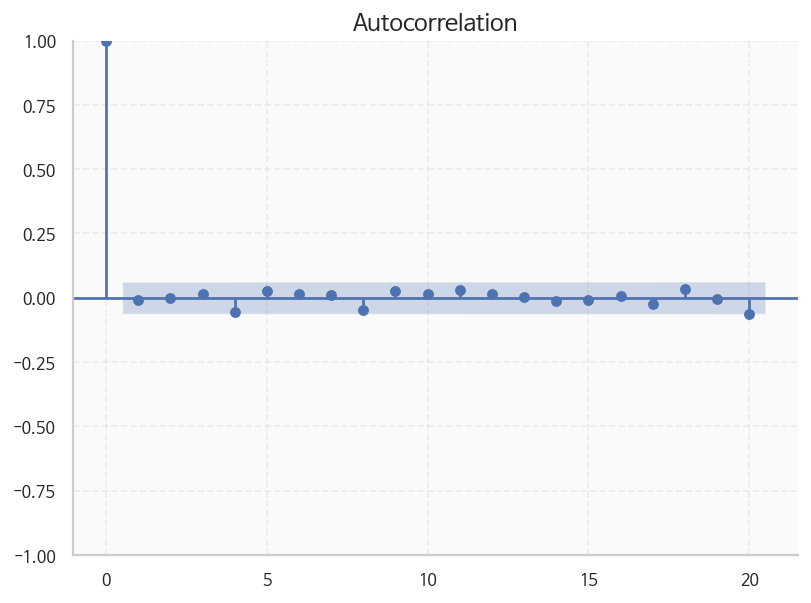

In [73]:
plot_acf(diff_random_walk, lags=20)
plt.tight_layout()
plt.show()

## Google 데이터 확인

In [74]:
df = pd.read_csv(DATA_PATH + 'GOOGL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


### 확률보행 확인
- ADF(Augmeted Dicked-Fuller Test) 테스트 적용
    + 귀무가설 : 주어진 시계열 데이터는 비정상 시계열이다(=정상성이 아니다)
    + 대립가설 : 주어진 시계열 데이터는 비정상 시계열이 아니다(=정상성이다)
  - 시계열 검정 진행 절차는 1차적으로 ADF 가설 검정을 만족해야 한다(귀무가설 기각 => 대립가설 채택)

In [79]:
GOOGLE_ADF_result = adfuller(df['Close'])
print(f'p-value: {GOOGLE_ADF_result[1]}')

p-value: 0.9699419435913057


In [80]:
diff_close = np.diff(df['Close'], n=1)

In [81]:
GOOGLE_diff_ADF_result = adfuller(diff_close)
print(f'p-value: {GOOGLE_diff_ADF_result[1]}')

p-value: 5.3865309614545585e-06


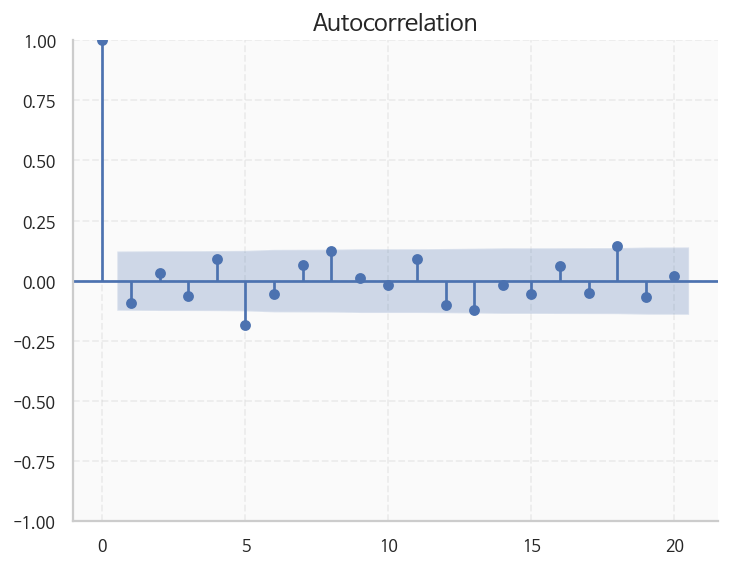

In [89]:
plot_acf(diff_close, lags=20);

# Google 주식 예측

In [90]:
df = pd.DataFrame({'value': random_walk})

train = df[:800]
test = df[800:]

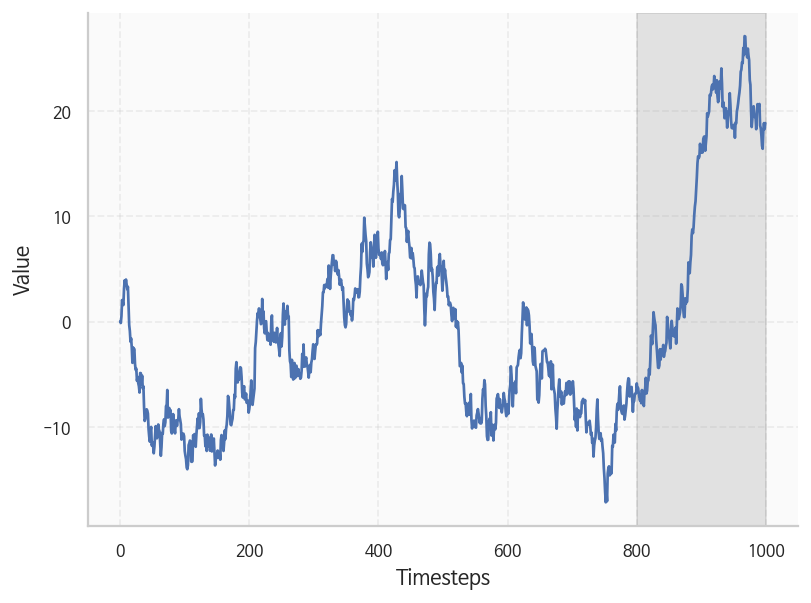

In [91]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(800, 1000, color='#808080', alpha=0.2)

plt.tight_layout()
plt.show()

## 과거의 평균 활용

In [92]:
mean = np.mean(train.value)
test.loc[:, 'pred_mean'] = mean
test.head()

/tmp/ipykernel_1103/3058291559.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_mean'] = mean


,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


In [93]:
last_value = train.iloc[-1].value
test.loc[:, 'pred_last'] = last_value
test.head()

/tmp/ipykernel_1103/2342727651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_last'] = last_value


,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


## 표류 기법 활용
- 마지막으로 측정된 값으로 예측하는 방법 수정
- 시간의 흐름에 따른 값의 증가나 감소 허용
- 훈련 집합의 첫번째 값과 마지막 값 사이의 기울기 계산한 뒤, 이 기울기를 미래에 단순히 외삽

In [94]:
deltaX = 800 - 1
deltaY = last_value - 0
drift = deltaY / deltaX
x_vals = np.arange(801, 1001, 1)
pred_drift = drift * x_vals
test.loc[:, 'pred_drift'] = pred_drift
test.head()

/tmp/ipykernel_1103/892297491.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_drift'] = pred_drift


,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.832006
801,-6.392708,-3.677206,-6.814947,-6.840536
802,-6.296588,-3.677206,-6.814947,-6.849065
803,-6.758863,-3.677206,-6.814947,-6.857594
804,-7.193359,-3.677206,-6.814947,-6.866124


## 예측 시각화 구현

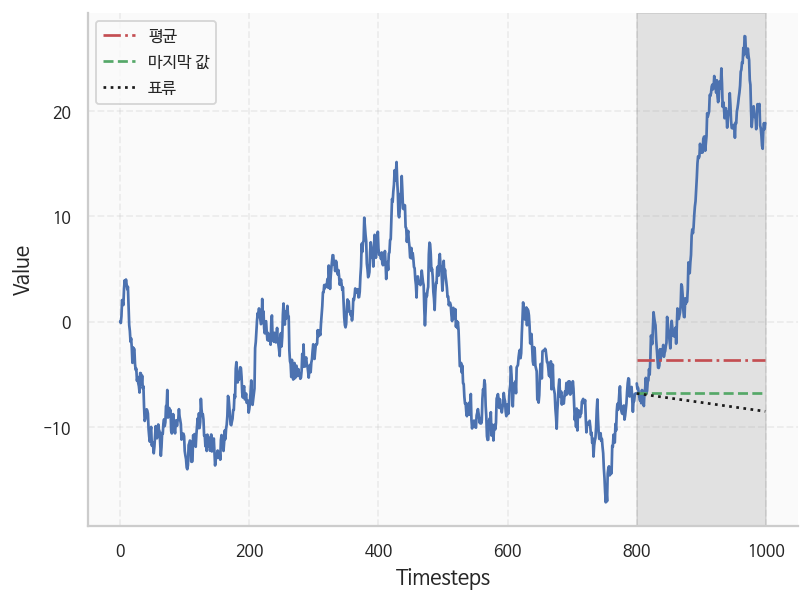

In [95]:
fig, ax = plt.subplots()

ax.plot(train.value, 'b-')
ax.plot(test['value'], 'b-')
ax.plot(test['pred_mean'], 'r-.', label='평균')
ax.plot(test['pred_last'], 'g--', label='마지막 값')
ax.plot(test['pred_drift'], 'k:', label='표류')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

## 예측모형 평가

In [ ]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last'])
mse_drift = mean_squared_error(test['value'], test['pred_drift'])

print(mse_mean, mse_last, mse_drift)

326.50277395297474 425.1726033055617 466.2172769077409
